In [1]:
import torch
import os
import shutil
from IPython.display import Image
from random import choice

In [2]:
imgs = []
xmls = []

ds_paths = {
    "train_path": "./deep-learning/datasets/traffic-signs-yolo/images/train",
    "train_label_path": "./deep-learning/datasets/traffic-signs-yolo/labels/train",
    "val_path": "./deep-learning/datasets/traffic-signs-yolo/images/val",
    "val_label_path": "./deep-learning/datasets/traffic-signs-yolo/labels/val"
}
source_path = "datasets/traffic-signs-yolo/ts"

In [18]:
for _, v in ds_paths.items():
    if not os.path.exists(v):
        os.makedirs(v)

train_ratio = 0.8
val_ratio = 0.2

In [19]:
total_img_count = len(os.listdir(source_path)) / 2

for (dirname, dirs, files) in os.walk(source_path):
    for filename in files:
        if filename.endswith(".txt"):
            xmls.append(filename)
        else:
            imgs.append(filename)

count_for_train = int(len(imgs) * train_ratio)
count_for_val = int(len(xmls) * val_ratio)

In [20]:
for x in range(count_for_train):
    file_jpg = choice(imgs)
    file_xml = file_jpg[:-4] + ".txt"

    shutil.copy(str(os.path.join(source_path, file_jpg)), str(os.path.join(ds_paths["train_path"], file_jpg)))
    shutil.copy(str(os.path.join(source_path, file_xml)), str(os.path.join(ds_paths["train_label_path"], file_xml)))

    imgs.remove(file_jpg)
    xmls.remove(file_xml)

for x in range(count_for_val):
    file_jpg = choice(imgs)
    file_xml = file_jpg[:-4] + ".txt"

    shutil.copy(str(os.path.join(source_path, file_jpg)), str(os.path.join(ds_paths["val_path"], file_jpg)))
    shutil.copy(str(os.path.join(source_path, file_xml)), str(os.path.join(ds_paths["val_label_path"], file_xml)))

    imgs.remove(file_jpg)
    xmls.remove(file_xml)

In [3]:
!python yolov5/train.py --data ./deep-learning/datasets/traffic-signs-yolo/dataset.yaml --weights yolov5s.pt --img 415 --batch 16 --epochs 30 --cache

train: weights=yolov5s.pt, cfg=, data=./deep-learning/datasets/traffic-signs-yolo/dataset.yaml, hyp=yolov5\data\hyps\hyp.scratch-low.yaml, epochs=30, batch_size=16, imgsz=415, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=yolov5\data\hyps, resume_evolve=None, bucket=, cache=ram, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=yolov5\runs\train, name=exp, exist_ok=False, quad=False, cos_lr=False, label_smoothing=0.0, patience=100, freeze=[0], save_period=-1, seed=0, local_rank=-1, entity=None, upload_dataset=False, bbox_interval=-1, artifact_alias=latest, ndjson_console=False, ndjson_file=False
github: up to date with https://github.com/ultralytics/yolov5 
YOLOv5  v7.0-398-g5cdad892 Python-3.12.9 torch-2.6.0+cpu CPU

hyperparameters: lr0=0.01, lrf=0.01, momentum=0.937, weight_decay=0.0005, warmup_epochs=3.0, warmup_momentum=0.8, warmup_bias_lr=0.1,

In [33]:
%load_ext tensorboard
%tensorboard --logdir runs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


ERROR: Failed to launch TensorBoard (exited with 1).
Contents of stderr:
2025-03-10 13:36:04.734264: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-10 13:36:05.307325: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Amir\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\Scripts\tensorboard.exe\__main__.py", line 7, in <module>
  File "C

In [25]:
!python ./yolov5/detect.py --source ./opencv-notebook/images/traffic_sign7.jpg  --weights ./yolov5/runs/train/exp7/weights/best.pt

detect: weights=['./yolov5/runs/train/exp7/weights/best.pt'], source=./opencv-notebook/images/traffic_sign7.jpg, data=yolov5\data\coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=yolov5\runs\detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5  v7.0-398-g5cdad892 Python-3.12.9 torch-2.6.0+cpu CPU

Fusing layers... 
Model summary: 157 layers, 7020913 parameters, 0 gradients, 15.8 GFLOPs
image 1/1 C:\Users\Amir\Desktop\test\Computer-Vision\opencv-notebook\images\traffic_sign7.jpg: 512x640 (no detections), 73.3ms
Speed: 1.0ms pre-process, 73.3ms inference, 0.0ms NMS per image at shape (1, 3, 640, 640)
Results saved to yolov5\runs\detect\exp11


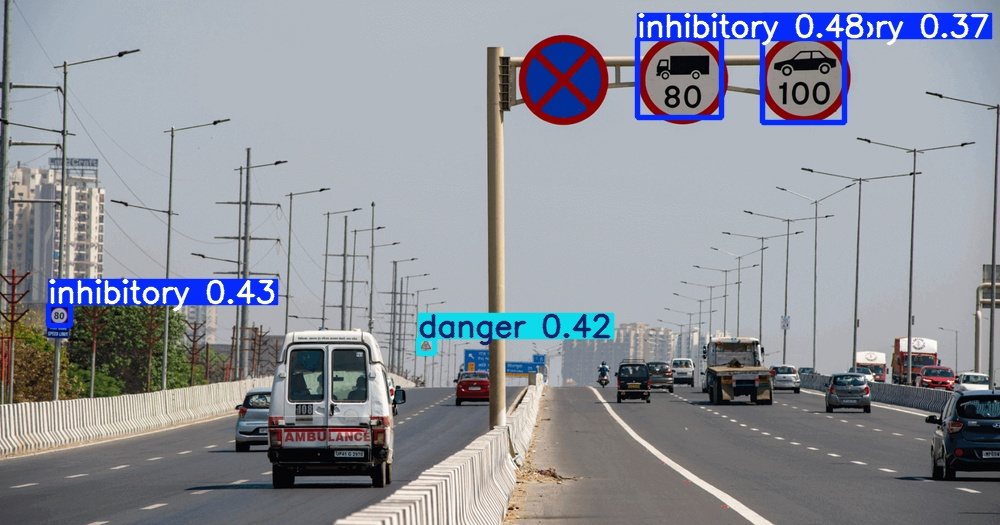

In [30]:
Image("./yolov5/runs/detect/exp9/traffic_sign5.jpg")